In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/nvidia_gpu_sales_synthetic_2026.csv')

df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56


In [3]:
print("df shape:", df.shape)
print()
df.info()

df shape: (7000, 17)

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sale_id                      7000 non-null   int64  
 1   sale_date                    7000 non-null   str    
 2   gpu_model                    7000 non-null   str    
 3   gpu_family                   7000 non-null   str    
 4   launch_year                  7000 non-null   int64  
 5   region                       7000 non-null   str    
 6   sales_channel                7000 non-null   str    
 7   customer_segment             7000 non-null   str    
 8   units_sold                   7000 non-null   int64  
 9   msrp_usd                     7000 non-null   int64  
 10  avg_street_price_usd         7000 non-null   float64
 11  price_premium_pct            7000 non-null   float64
 12  stock_status                 7000 non-null   str    
 13  custome

In [4]:
print(df.isnull().sum())

print("Duplicate Rows", df.duplicated().sum())

df['sale_date'] = pd.to_datetime(df['sale_date'])

print(df['sale_date'].dtype)

sale_id                           0
sale_date                         0
gpu_model                         0
gpu_family                        0
launch_year                       0
region                            0
sales_channel                     0
customer_segment                  0
units_sold                        0
msrp_usd                          0
avg_street_price_usd              0
price_premium_pct                 0
stock_status                      0
customer_satisfaction_score       0
warranty_months                   0
bundle_addon                   3841
revenue_usd                       0
dtype: int64
Duplicate Rows 0
datetime64[us]


In [5]:
df.describe()

df[['units_sold','msrp_usd','price_premium_pct','customer_satisfaction_score','revenue_usd']].describe()

,units_sold,msrp_usd,price_premium_pct,customer_satisfaction_score,revenue_usd
count,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,21.674143,5212.903857,15.010536,4.428286,5.658006e+04
std,12.928136,11056.780783,14.348016,0.608437,9.996269e+04
min,1.000000,549.000000,0.000000,1.500000,1.393130e+03
25%,12.000000,749.000000,4.560000,4.000000,1.555133e+04
50%,20.000000,999.000000,8.850000,4.500000,2.534293e+04
75%,29.000000,1599.000000,21.352500,5.000000,4.670657e+04
max,104.000000,42000.000000,98.460000,5.000000,1.225726e+06


In [6]:
df['gpu_family'].value_counts()

gpu_family
Consumer Gaming    5923
Data Center AI     1077
Name: count, dtype: int64

In [7]:
df.groupby('gpu_family')['revenue_usd'].agg(['sum','mean','count'])

,sum,mean,count
gpu_family,,,
Consumer Gaming,1.629497e+08,27511.348344,5923
Data Center AI,2.331107e+08,216444.509183,1077


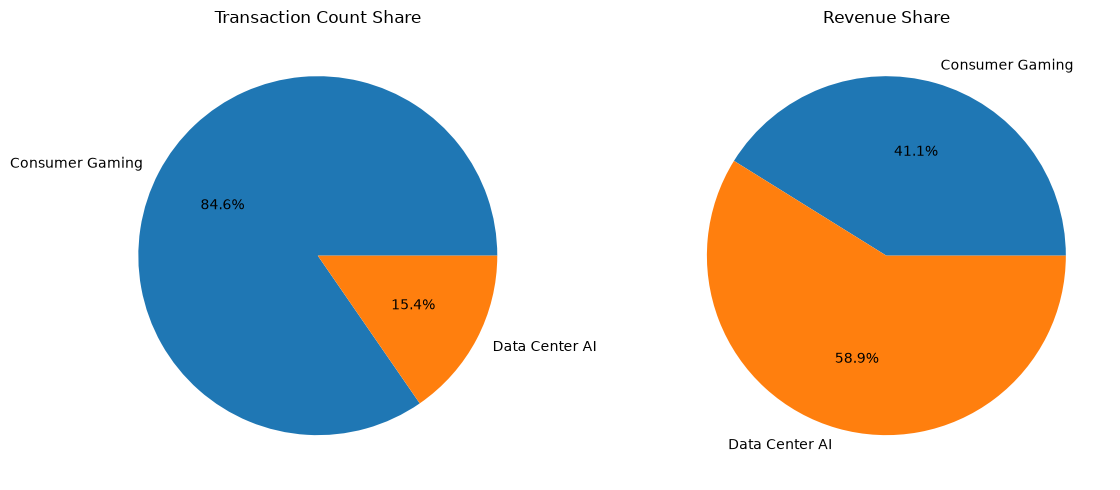

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

df['gpu_family'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Transaction Count Share')
axes[0].set_ylabel('')

df.groupby('gpu_family')['revenue_usd'].sum().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Revenue Share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [9]:
df.groupby('gpu_family').agg(
    avg_price=('avg_street_price_usd', 'mean'),
    avg_units_per_txn = ('units_sold', 'mean'),
    total_units=('units_sold', 'sum')
)

,avg_price,avg_units_per_txn,total_units
gpu_family,,,
Consumer Gaming,1125.355880,24.428837,144692
Data Center AI,33082.178245,6.524605,7027


In [10]:
df.groupby('stock_status')['price_premium_pct'].agg(['mean','median','max','count']).sort_values('mean', ascending=False)

,mean,median,max,count
stock_status,,,,
Sold Out,44.950299,44.080,98.46,669
Backordered,27.889756,27.820,73.24,1268
Low Stock,13.856773,13.755,37.96,1946
In Stock,4.065611,4.030,11.90,3117


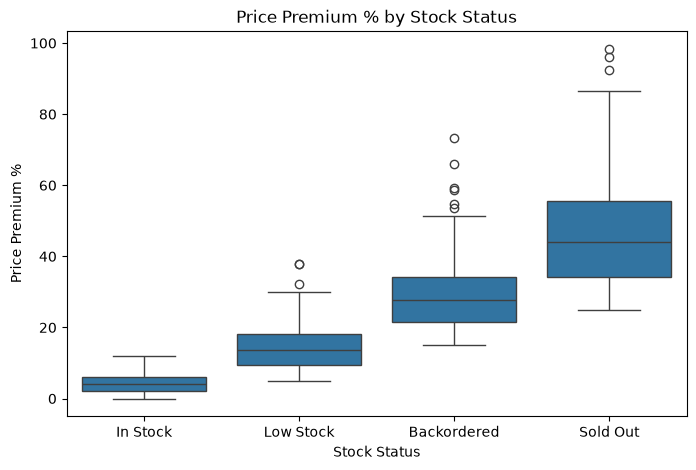

In [11]:
plt.figure(figsize=(8,5))
order = ['In Stock', 'Low Stock', 'Backordered', 'Sold Out']
sns.boxplot(data=df, x='stock_status', y='price_premium_pct', order=order)
plt.title('Price Premium % by Stock Status')
plt.xlabel('Stock Status')
plt.ylabel('Price Premium %')
plt.show()

In [12]:
df.groupby('customer_segment')['price_premium_pct'].agg(['mean','median','count']).sort_values('mean', ascending=False)

,mean,median,count
customer_segment,,,
Crypto Mining,18.650615,9.960,179
Hyperscale Datacenter,15.884606,9.370,584
Content Creation,15.567476,9.550,1161
AI Research/Startup,15.416656,10.905,314
Gaming,14.603950,8.270,4762


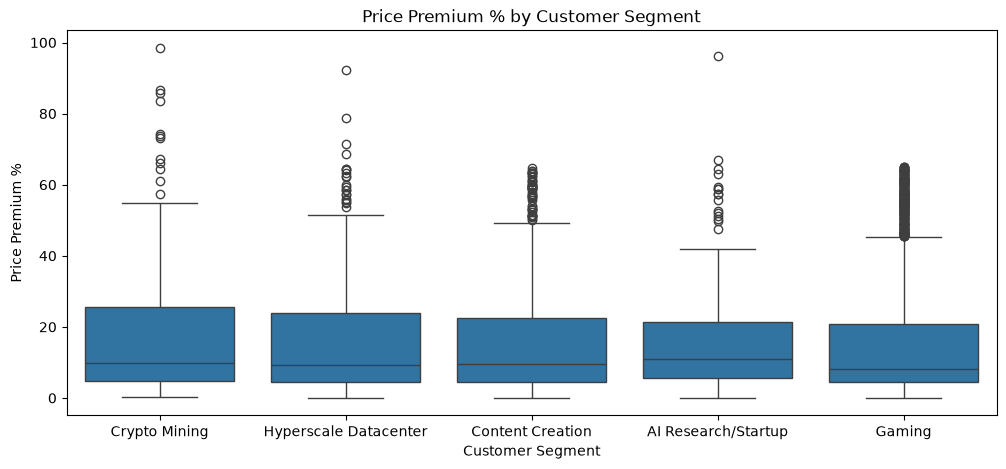

In [13]:
plt.figure(figsize=(12,5))
rank = ['Crypto Mining','Hyperscale Datacenter', 'Content Creation', 'AI Research/Startup', 'Gaming']
sns.boxplot(data=df, x= 'customer_segment', y = 'price_premium_pct', order = rank)
plt.title ('Price Premium % by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Price Premium %')
plt.show()

In [20]:
df.groupby('sales_channel')['revenue_usd'].agg(['sum','mean','count'])

,sum,mean,count
sales_channel,,,
Cloud Provider,1.123999e+08,212075.319491,530
Direct Enterprise,8.395026e+07,226892.587162,370
Retail/Etail,1.216032e+08,27271.411749,4459
System Integrator/OEM,7.810705e+07,47597.227946,1641


In [19]:
df.groupby(['sales_channel','region'])['revenue_usd'].agg(['sum','mean','count'])

sum           mean  \
sales_channel         region                                                
Cloud Provider        Asia-Pacific (ex-China)  22085964.42  208358.154906   
                      China                    21246182.35  221314.399479   
                      Europe                   23517888.94  228329.018835   
                      North America            36018929.03  205822.451600   
                      Rest of World             9530954.59  190619.091800   
Direct Enterprise     Asia-Pacific (ex-China)  24425452.65  249239.312755   
                      China                    12103416.07  216132.429821   
                      Europe                   18562105.79  215838.439419   
                      North America            23302651.66  219836.336415   
                      Rest of World             5556631.08  231526.295000   
Retail/Etail          Asia-Pacific (ex-China)  25553079.86   27957.417790   
                      China                    18231005.59   27961.665015   
                      Europe                   28866217.43   26242.015845   
                      North America            39849125.94   27425.413586   
                      Rest of World             9103796.17   26775.871088   
System Integrator/OEM Asia-Pacific (ex-China)  16600808.42   50766.998226   
                      China                    13024848.81   48600.182127   
                      Europe                   20166848.49   50417.121225   
                      North America            22199493.40   43189.675875   
                      Rest of World             6115051.94   46326.151061   

                                               count  
sales_channel         region                          
Cloud Provider        Asia-Pacific (ex-China)    106  
                      China                       96  
                      Europe                     103  
                      North America              175  
                      Rest of World               50  
Direct Enterprise     Asia-Pacific (ex-China)     98  
                      China                       56  
                      Europe                      86  
                      North America              106  
                      Rest of World               24  
Retail/Etail          Asia-Pacific (ex-China)    914  
                      China                      652  
                      Europe                    1100  
                      North America             1453  
                      Rest of World              340  
System Integrator/OEM Asia-Pacific (ex-China)    327  
                      China                      268  
                      Europe                     400  
                      North America              514  
                      Rest of World              132

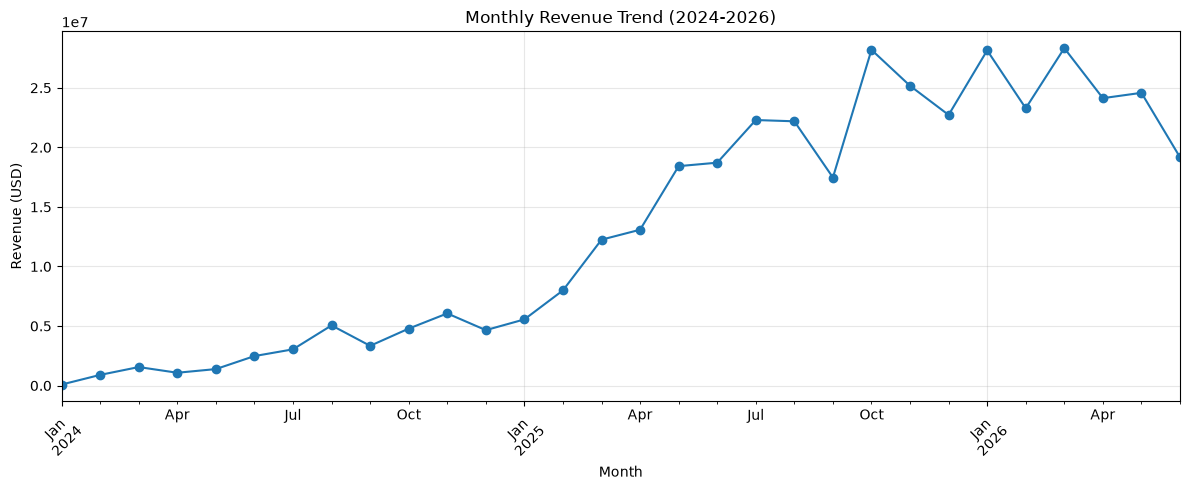

In [14]:
monthly_revenue = df.groupby(df['sale_date'].dt.to_period('M'))['revenue_usd'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind = 'line', marker= 'o')
plt.title('Monthly Revenue Trend (2024-2026)')
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.grid(True, alpha= 0.3)
plt.tight_layout()
plt.show()

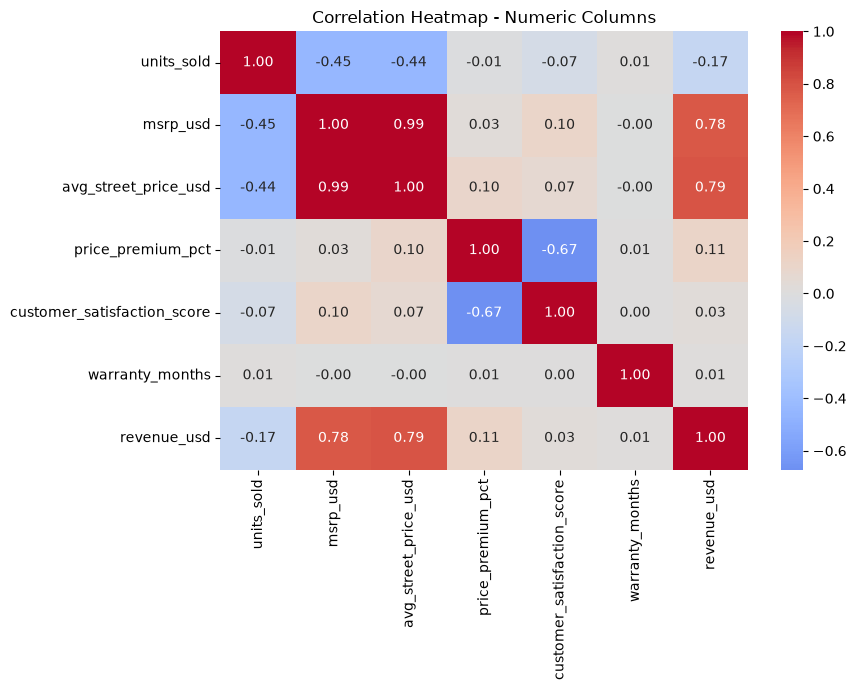

In [15]:
numeric_cols = ['units_sold', 'msrp_usd', 'avg_street_price_usd', 'price_premium_pct', 'customer_satisfaction_score', 'warranty_months', 'revenue_usd']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center =0)
plt.title('Correlation Heatmap - Numeric Columns')
plt.tight_layout()
plt.show()

In [16]:
import sqlite3

conn = sqlite3.connect('nvidia_gpu_sales.db')
df.to_sql('gpu_sales',conn, if_exists='replace', index=False)
conn.close()

print("Database created successfully")

Database created successfully
